# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Nathan Adrian Chandra]
- **Email:** [AIC244B6Y0050@student.devacademy.id]
- **ID Dicoding:** [nathadr]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Berapa persentase pelanggan (Customer Unique ID) yang melakukan pembelian ulang (repeat order) lebih dari 1 kali di negara bagian São Paulo (SP) dibandingkan Rio de Janeiro (RJ) sepanjang tahun 2017?
- **Pertanyaan 2:** Apakah rata-rata skor ulasan (Review Score) untuk kategori produk 'cama_mesa_banho' mengalami penurunan di bawah 4.0 bintang akibat keterlambatan pengiriman (waktu pengiriman aktual melebihi estimasi) selama periode kuartal pertama (Q1) tahun 2018?
- **Pertanyaan 3:** Berapa kontribusi nilai transaksi (Payment Value) dan jumlah cicilan (Payment Installments) dengan menggunakan metode 'credit_card' pada kategori produk bernilai tinggi seperti 'watches_gifts' selama periode semester kedua (H2) tahun 2017?

In [1]:
#untuk menghubungkan ke google drive karena dataset ada dalam drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Semua Packages/Library yang Digunakan

In [2]:
#import semua library yang dibutuhkan untuk analisis data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load semua df yang dibutuhkan untuk menjawab pertanyaan bisnis

In [3]:
#load dataset customer dan menampilkan 5 data pertama
customer_df = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/customers_dataset.csv')
customer_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
#load dataset order dan menampilkan 5 data pertama
orders_df = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/orders_dataset.csv')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
#load dataset order items dan menampilkan 5 data pertama
orders_items_df = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/order_items_dataset.csv')
orders_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
#load dataset product dan menampilkan 5 data pertama
products_df = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/products_dataset.csv')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [7]:
#load dataset order review dan menampilkan 5 data pertama
orders_review_df = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/order_reviews_dataset.csv')
orders_review_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [8]:
#load dataset order payment dan menampilkan 5 data pertama
orders_payments_df = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/order_payments_dataset.csv')
orders_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


**Insight:** (Opsional)
- Mengubah data mentah menjadi format tabel interaktif (Dataframe Pandas) sehingga mudah diolah
- Menggunakan dataset customer, products, orders, orders_item, orders_payment, orders_review untuk menjawab pertanyaan bisnis

### Assessing Data

#### Identifying Missing Value, Duplicated Data, Inaccurate Value, Wrong Data Type problem

In [9]:
#melihat tipe data customer untuk mengecek apa sudah sesuai semua / perlu cleaning
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [10]:
#melihat jumlah data customer yang missing value
customer_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [11]:
#melihat jumlah data customer yang duplikat
print(f'Jumlah duplikasi data customer: {customer_df.duplicated().sum()}')

Jumlah duplikasi data customer: 0


In [12]:
#melihat informasi statistik umum pada data customer
customer_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [13]:
#cek tipe data order
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [14]:
#cek missing value data order
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [15]:
#menampilkan jumlah data duplikat data order
print(f'Jumlah duplikasi data orders: {orders_df.duplicated().sum()}')

Jumlah duplikasi data orders: 0


In [16]:
#cek informasi statistik umum dari data order
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [17]:
#cek tipe data order items
orders_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [18]:
#cek missing value data order item
orders_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [19]:
#cek jumlah data duplikat dari order item
print(f'Jumlah duplikasi data orders items: {orders_items_df.duplicated().sum()}')

Jumlah duplikasi data orders items: 0


In [20]:
#cek informasi statistik umum dari data order item
orders_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [21]:
#cek tipe data order payment
orders_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [22]:
#cek missing value data order payment
orders_payments_df.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [23]:
#tampil jumlah data duplikat dari data order payment
print(f'Jumlah duplikasi data orders payments: {orders_payments_df.duplicated().sum()}')

Jumlah duplikasi data orders payments: 0


In [24]:
#informasi statistik umum data order payment
orders_payments_df.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [25]:
#cek tipe data order review
orders_review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [26]:
#cek missing value data order review
orders_review_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [27]:
#cek jumlah data duplikat dari order review
print(f'Jumlah duplikasi data orders review: {orders_review_df.duplicated().sum()}')

Jumlah duplikasi data orders review: 0


In [28]:
#cek statistik umum dari data order review
orders_review_df.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [29]:
#cek tipe data product
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [30]:
#cek missing value data products
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [31]:
#cek jumlah data duplikat dari data products
print(f'Jumlah duplikasi data products: {products_df.duplicated().sum()}')

Jumlah duplikasi data products: 0


In [32]:
#informasi statistik umum dari data products
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Steps to Take:**
* **Tindakan Perbaikan:** Mengeksekusi dan memperbaiki temuan dari tahap *Assessing*.
* **Mengisi/menangani** kekosongan pada *missing value*.
* **Memperbaiki format** tipe data (misal: merubah format teks menjadi tipe *datetime* pada kolom tanggal).

**Insight:** (Opsional)
- Pada dataset orders, ditemukan wrong data type pada order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date seharusnya **datetime** bukan object. Selain itu ditemukan, ada missing value pada order_approved_at sejumlah 160, order_delivered_carrier_date sejumlah 1783, dan order_delivered_customer_date sejumlah 2965.
- Pada dataset orders_items, ditemukan wrong data type pada shipping_limit_date seharusnya datetime
- Pada dataset orders_reviews, ditemukan wrong data type pada review_creation_date dan review_answer_timestamp seharusnya datetime bukan object. Selain itu ditemukan missing value pada review_comment_title sebanyak 87656 dan review_comment_message sebanyak 58247.
- Pada dataset products, ditemukan missing values pada product_category_name sebanyak 610, product_name_length sebanyak 610, product_description_length sebanyak 610, product_photos_qty sebnayak 610, product_weight_g = 2, product_length_cm = 2, product_height_cm = 2, product_width_cm = 2.

### Cleaning Data

#### Fixing Missing Value dan Data Type problem

In [33]:
#mengubah tipe data yang sblmnya tidak tepat seperti 'object' menjadi 'datetime'
datetime_columns = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]

for column in datetime_columns:
  orders_df[column] = pd.to_datetime(orders_df[column])

In [34]:
#cek kembali tipe datanya apakah sudah benar
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [35]:
#tampil data order pada order_approved_at yang missing value untuk melihat dulu
orders_df[orders_df.order_approved_at.isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaT,NaT,NaT,2018-09-12
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaT,NaT,NaT,2018-10-17
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaT,NaT,NaT,2017-04-10
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaT,NaT,NaT,2018-09-13
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaT,NaT,NaT,2017-05-30
...,...,...,...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaT,NaT,NaT,2017-07-25
98415,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaT,NaT,NaT,2017-10-16
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaT,NaT,NaT,2018-08-10
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01


In [36]:
#tampil data order pada order_delivered_carrier_data yang missing value untuk melihat dulu
orders_df[orders_df.order_delivered_carrier_date.isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03
266,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaT,NaT,2017-12-05
324,d3c8851a6651eeff2f73b0e011ac45d0,957f8e082185574de25992dc659ebbc0,processing,2016-10-05 22:44:13,2016-10-06 15:51:05,NaT,NaT,2016-12-09
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaT,NaT,2018-02-06
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaT,NaT,NaT,2018-09-27
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaT,NaT,2017-09-15


In [37]:
#tampil data order pada order_delivered_customer_date yang missing value untuk melihat dulu
orders_df[orders_df.order_delivered_customer_date.isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT,2018-06-28
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaT,2018-02-07
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaT,NaT,2018-02-06
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaT,NaT,NaT,2018-09-27
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaT,NaT,2017-09-15


In [38]:
#copy data order dimana order_status = delivered untuk menghindari perubahan langsung pada dataset asli sehingga kalau ada salah masih bisa lihat data asli
orders_df_clean = orders_df[orders_df['order_status'] == 'delivered'].copy()

orders_df_clean

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [39]:
#mengatasi missing value pada order_approved_at dengan data order_purchase_timestamp. asumsinya: approved_at biasanya = order_purchase
orders_df_clean['order_approved_at'] = orders_df_clean['order_approved_at'].fillna(orders_df_clean['order_purchase_timestamp'])

In [40]:
#menghapus missing value sisanya, karena data kotor yang tidak bisa digunakan ataupun diperbaiki
orders_df_clean.dropna(subset=['order_delivered_carrier_date', 'order_delivered_customer_date'], inplace=True)

In [41]:
orders_df_clean.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


In [71]:
#mengubah menjadi tipe data date_time untuk shipping_limit_date

orders_items_df['shipping_limit_date'] = pd.to_datetime(orders_items_df['shipping_limit_date'])

In [43]:
#cek kembali apa sudah benar
orders_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [44]:
#ubah tipe data menjadi datetime untuk review_creation_date dan review_answer_timestamp
datetime_columns = ["review_creation_date", "review_answer_timestamp"]

for column in datetime_columns:
  orders_review_df[column] = pd.to_datetime(orders_review_df[column])

In [45]:
#Cek kembali hasilnya
orders_review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [46]:
#tampil data missing value review_comment_title
orders_review_df[orders_review_df.review_comment_title.isna()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01,2018-07-02 12:59:13


In [47]:
#tampil data missing value review_comment_message
orders_review_df[orders_review_df.review_comment_message.isna()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16,2017-07-18 19:30:34
...,...,...,...,...,...,...,...
99217,c6b270c61f67c9f7cb07d84ea8aeaf8b,48f7ee67313eda32bfcf5b9c1dd9522d,5,NaN,NaN,2017-12-13,2017-12-14 11:09:36
99218,af2dc0519de6e0720ef0c74292fb4114,d699c734a0b1c8111f2272a3f36d398c,5,NaN,NaN,2018-04-27,2018-04-30 01:18:57
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09,2017-12-11 20:06:42


In [48]:
#handle missing value pada review_comment_message dan review_comment_title dengan '' agar tidak mengganggu
orders_review_df['review_comment_message'].fillna('', inplace=True)
orders_review_df['review_comment_title'].fillna('', inplace=True)

/tmp/ipykernel_1042/3517115361.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orders_review_df['review_comment_message'].fillna('', inplace=True)
/tmp/ipykernel_1042/3517115361.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

In [49]:
#cek kembali missing value
orders_review_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,0
review_comment_message,0
review_creation_date,0
review_answer_timestamp,0


In [50]:
#tampil missing value product_category_name
products_df[products_df.product_category_name.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [51]:
#tampil missing value product_name_lenght
products_df[products_df.product_name_lenght.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [52]:
#tampil missing value product_description_lenght
products_df[products_df.product_description_lenght.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [53]:
#tampil missing value prodct_photos_qty
products_df[products_df.product_photos_qty.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [54]:
#tampil missing value product_weight_g
products_df[products_df.product_weight_g.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
#tampil missing value product_lenght_cm
products_df[products_df.product_length_cm.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
#tampil missing value product_height_cm
products_df[products_df.product_height_cm.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
#tampil missing value product_width_cm
products_df[products_df.product_width_cm.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
#mengisi missing value pada product_category_name dengan unknown karena akan menjadi masalah kalau asal isi / berasumsi
products_df['product_category_name'].fillna('unknown', inplace=True)

/tmp/ipykernel_1042/3831722995.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df['product_category_name'].fillna('unknown', inplace=True)


In [59]:
#di isi 0 untuk missing value product_name_lenght, product_description_lenght, dan product_photos_qty
cols_to_zero = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty']
for col in cols_to_zero:
    products_df[col] = products_df[col].fillna(0)

In [60]:
#isi dengan median karena lebih robust terhadap outlier untuk product_weight_g, product_length_cm, product_height_cm, dan product_width_cm
cols_to_median = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in cols_to_median:
    median_value = products_df[col].median()
    products_df[col] = products_df[col].fillna(median_value)


In [61]:
#cek kembali missing value
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


**Insight:** (Opsional)
- Tipe data object pada atribut data bersifat datetime sudah berubah menjadi tipe datetime
- Missing value sudah terhandle dengan berbagai pendekatan tergantung atribut data dan tujuan pertanyaan bisnis yang dicapai

## Exploratory Data Analysis (EDA)

### Explore Data Analysis berdasarkan 3 pertanyaan bisnis yang dibuat

In [68]:
#mengambil data order_purchase_timestamp pada tahun 2017 dan menggabungkan data orders dan customer dengan cara inner. Setelah itu ambil customer_state di SP dan RJ serta count total_orders. Kalau >1 maka repeated
orders_2017 = orders_df_clean[orders_df_clean['order_purchase_timestamp'].dt.year == 2017]

customer_orders_2017 = pd.merge(
    orders_2017,
    customer_df,
    on="customer_id",
    how="inner"
)

eda_q1 = customer_orders_2017[customer_orders_2017['customer_state'].isin(['SP', 'RJ'])]

order_counts = eda_q1.groupby(['customer_state', 'customer_unique_id']).size().reset_index(name='total_orders')

order_counts['is_repeat'] = order_counts['total_orders'] > 1

repeat_summary = order_counts.groupby('customer_state')['is_repeat'].value_counts(normalize=True).unstack() * 100
print("Persentase Pelanggan (Repeat vs Single Order)")
print(repeat_summary)

Persentase Pelanggan (Repeat vs Single Order)
is_repeat           False     True 
customer_state                     
RJ              97.236138  2.763862
SP              97.130430  2.869570


In [73]:
#ambil data q1 pada tahun 2018 untuk order lalu cek is_delayed dengan order_delivered > order_estimated setelah itu cek untuk cama_mesa_banho
q1_2018_orders = orders_df_clean[
    (orders_df_clean['order_purchase_timestamp'] >= '2018-01-01') &
    (orders_df_clean['order_purchase_timestamp'] <= '2018-03-31')
]

q1_2018_orders['is_delayed'] = q1_2018_orders['order_delivered_customer_date'] > q1_2018_orders['order_estimated_delivery_date']

merge_step1 = pd.merge(q1_2018_orders, orders_items_df, on='order_id', how='inner')
merge_step2 = pd.merge(merge_step1, products_df, on='product_id', how='inner')
eda_q2 = pd.merge(merge_step2, orders_review_df, on='order_id', how='inner')

eda_q2_filtered = eda_q2[eda_q2['product_category_name'] == 'cama_mesa_banho']

review_by_delivery = eda_q2_filtered.groupby('is_delayed')['review_score'].agg(['mean', 'count', 'median'])
print("Analisis Skor Ulasan Kategori 'bed_bath_table' di Q1 2018")
print(review_by_delivery)

/tmp/ipykernel_1042/626081052.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  q1_2018_orders['is_delayed'] = q1_2018_orders['order_delivered_customer_date'] > q1_2018_orders['order_estimated_delivery_date']


Analisis Skor Ulasan Kategori 'bed_bath_table' di Q1 2018
                mean  count  median
is_delayed                         
False       3.948731   1931     5.0
True        2.374286    350     1.0


In [70]:
#ambil data 2017 order , mengambil data payment_value dan payment_installments
h2_2017_orders = orders_df_clean[
    (orders_df_clean['order_purchase_timestamp'] >= '2017-07-01') &
    (orders_df_clean['order_purchase_timestamp'] <= '2017-12-31')
]

m1 = pd.merge(h2_2017_orders, orders_payments_df, on='order_id', how='inner')
m2 = pd.merge(m1, orders_items_df, on='order_id', how='inner')
eda_q3 = pd.merge(m2, products_df, on='product_id', how='inner')

eda_q3_filtered = eda_q3[
    (eda_q3['payment_type'] == 'credit_card') &
    (eda_q3['product_category_name'] == 'relogios_presentes')
]

total_payment_value = eda_q3_filtered['payment_value'].sum()
print(f"Total Nilai Transaksi Kartu Kredit (Watches Gifts H2 2017): {total_payment_value:,.2f}")

installments_distribution = eda_q3_filtered['payment_installments'].value_counts().sort_index()
print("\n Distribusi Jumlah Cicilan yang Dipilih Pelanggan")
print(installments_distribution)

Total Nilai Transaksi Kartu Kredit (Watches Gifts H2 2017): 334,264.15

 Distribusi Jumlah Cicilan yang Dipilih Pelanggan
payment_installments
1     262
2     216
3     197
4     170
5     118
6      82
7      44
8     200
9      13
10     92
12      1
14      1
15      2
21      3
24      2
Name: count, dtype: int64


## Visualization & Explanatory Analysis

### Pertanyaan 1: Berapa persentase pelanggan (Customer Unique ID) yang melakukan pembelian ulang (repeat order) lebih dari 1 kali di negara bagian São Paulo (SP) dibandingkan Rio de Janeiro (RJ) sepanjang tahun 2017?

<Figure size 700x500 with 0 Axes>

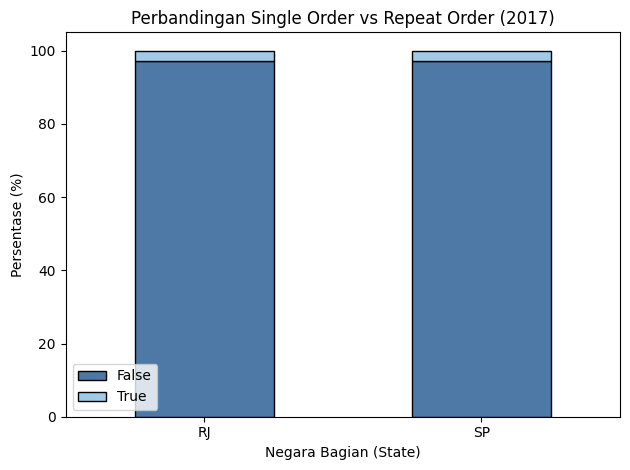

In [65]:
#visualisasi eda
plt.figure(figsize=(7, 5))
repeat_summary.plot(kind='bar', stacked=True, color=['#4e79a7', '#a0cbe8'], edgecolor='black')
plt.title('Perbandingan Single Order vs Repeat Order (2017)')
plt.ylabel('Persentase (%)')
plt.xlabel('Negara Bagian (State)')
plt.xticks(rotation=0)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Per tahun 2017, ternyata untuk state customer yang berada di (RJ) Rio de Janeiro dan (SP) Sao Paolo sama-sama sedikit yang melakukan repeat order hanya berkisaran 2.7-2.8%, mayoritas hanya melakukan single order saja kisaran 97% sehingga bisa menjadi perhatian dan dipersiapkan planning / skema untuk kedua state tersebut karena tingkat retensi kedua state tersebut sangatlah rendah

### Pertanyaan 2: Apakah rata-rata skor ulasan (Review Score) untuk kategori produk 'bed_bath_table' mengalami penurunan di bawah 4.0 bintang akibat keterlambatan pengiriman (waktu pengiriman aktual melebihi estimasi) selama periode kuartal pertama (Q1) tahun 2018?

/tmp/ipykernel_1042/3022112531.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_delayed', y='mean', data=plot_data, palette=['#2ca02c', '#d62728'])


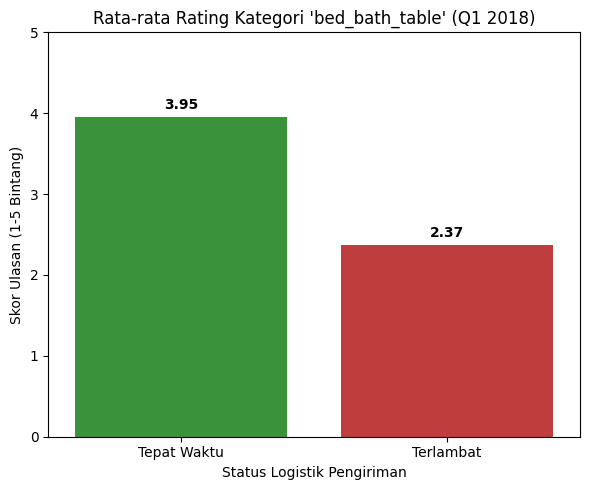

In [ ]:
#visualisasi eda
plot_data = review_by_delivery.reset_index()

plot_data['is_delayed'] = plot_data['is_delayed'].map({False: 'Tepat Waktu', True: 'Terlambat'})

plt.figure(figsize=(6, 5))

sns.barplot(x='is_delayed', y='mean', data=plot_data, palette=['#2ca02c', '#d62728'])

plt.title("Rata-rata Rating Kategori 'cama_mesa_banho' (Q1 2018)")
plt.ylabel('Skor Ulasan (1-5 Bintang)')
plt.xlabel('Status Logistik Pengiriman')
plt.ylim(0, 5)

for index, row in plot_data.iterrows():
    plt.text(index, row['mean'] + 0.1, f"{row['mean']:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Per Q1 tahun 2018, ketika suatu barang sampai kepada pelanggan delayed dari estimasi sampainya memungkinkan untuk mempengaruhi kepuasan pelanggan. Terlihat dari is_delayed = True, ketika analisis mean dan mediannya, ternyata rata-rata ratingnya sebesar 2.3 dan nilai tengahnya 1.0 (dimana rendah sekali) untuk 350 data. Di sisi lain, ketika tidak delay rata-rata review nya cukup besar yaitu 3.9 dengan median 5.0 untuk 1931 data. Yang perlu di take note bahwa ada perbedaan jumlah data yang cukup besar (selisih data = 1581 data) sehingga bisa dicek dari sisi lain juga, tidak bisa langsung dikatakan positif pasti pengaruh.

### Pertanyaan 3: Berapa kontribusi nilai transaksi (Payment Value) dan jumlah cicilan (Payment Installments) dengan menggunakan metode 'credit_card' pada kategori produk bernilai tinggi seperti 'watches_gifts' selama periode semester kedua (H2) tahun 2017?

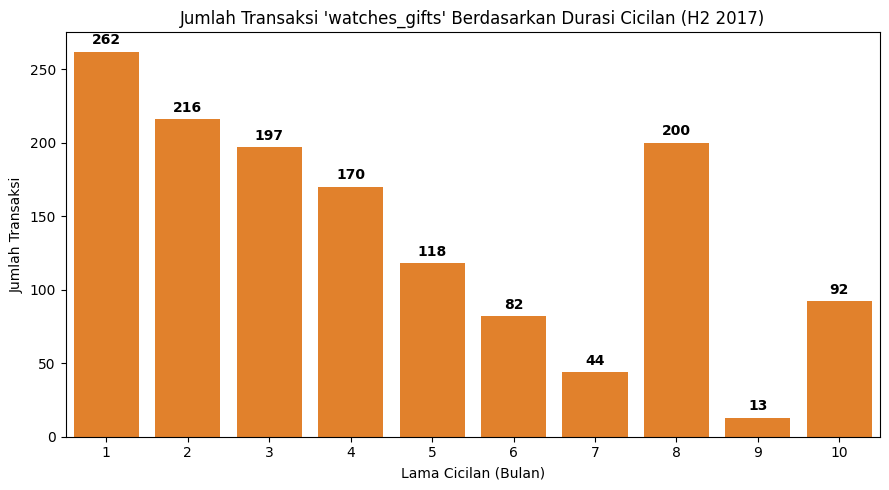

In [67]:
#visualisasi eda
plot_data_q3 = installments_distribution.reset_index()
plot_data_q3.columns = ['Tenor Cicilan (Bulan)', 'Jumlah Transaksi']

plt.figure(figsize=(9, 5))
sns.barplot(x='Tenor Cicilan (Bulan)', y='Jumlah Transaksi', data=plot_data_q3.head(10), color='#ff7f0e')

plt.title("Jumlah Transaksi 'watches_gifts' Berdasarkan Durasi Cicilan (H2 2017)")
plt.ylabel('Jumlah Transaksi')
plt.xlabel('Lama Cicilan (Bulan)')

for index, row in plot_data_q3.head(10).iterrows():
    plt.text(index, row['Jumlah Transaksi'] + 5, f"{int(row['Jumlah Transaksi'])}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Pada semester kedua tahun 2017 (H2 2017), total transaksi kategori Watches Gifts  metode pembayaran kartu kredit mencapai sekitar 334 ribu. Mayoritas pelanggan memilih pembayaran dengan cicilan rendah, terutama 1–4 kali cicilan, yang menunjukkan kecenderungan pelanggan untuk melunasi pembayaran lebih cepat.
Ada sebagian pelanggan yang memilih cicilan lebih panjang seperti 8 dan 10 kali, yang mengindikasikan adanya kebutuhan fleksibilitas pembayaran pada produk kategori ini. Hal ini dapat menjadi peluang bagi perusahaan untuk menawarkan promo cicilan atau kerja sama kartu kredit guna meningkatkan daya beli pelanggan.


## Analisis Lanjutan (Opsional)

In [74]:
rfm_df = pd.merge(
    orders_df_clean,
    orders_payments_df,
    on='order_id',
    how='inner'
)


ambil_date = rfm_df['order_purchase_timestamp'].max()

#Menghitung jumlah hari sejak terakhir kali pelanggan melakukan pembelian.
recency = rfm_df.groupby('customer_id')['order_purchase_timestamp'].max().reset_index()
recency['Recency'] = (ambil_date - recency['order_purchase_timestamp']).dt.days

#Menghitung jumlah total transaksi yang dilakukan oleh pelanggan dalam periode tertentu.
frequency = rfm_df.groupby('customer_id')['order_id'].count().reset_index()
frequency.columns = ['customer_id', 'Frequency']

#Menghitung total pengeluaran pelanggan dalam periode tersebut.
monetary = rfm_df.groupby('customer_id')['payment_value'].sum().reset_index()
monetary.columns = ['customer_id', 'Monetary']

rfm = pd.merge(recency[['customer_id', 'Recency']], frequency, on='customer_id')
rfm = pd.merge(rfm, monetary, on='customer_id')

print(rfm.head())

                        customer_id  Recency  Frequency  Monetary
0  00012a2ce6f8dcda20d059ce98491703      287          1    114.74
1  000161a058600d5901f007fab4c27140      409          1     67.41
2  0001fd6190edaaf884bcaf3d49edf079      547          1    195.42
3  0002414f95344307404f0ace7a26f1d5      378          1    179.35
4  000379cdec625522490c315e70c7a9fb      149          1    107.01


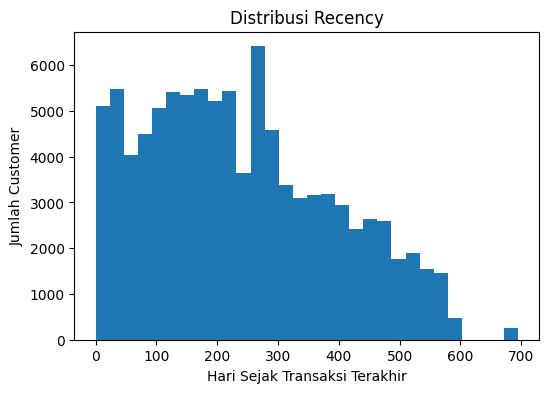

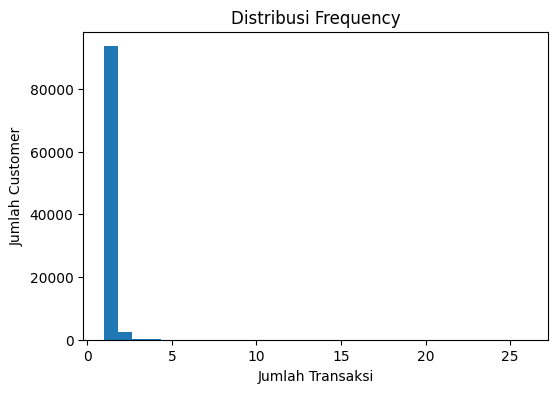

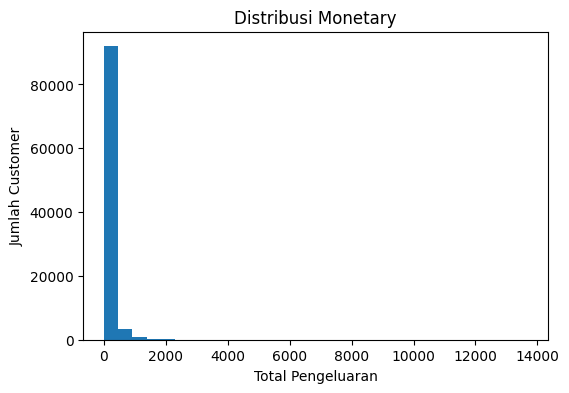

In [75]:

plt.figure(figsize=(6,4))
plt.hist(rfm['Recency'], bins=30)
plt.title('Distribusi Recency')
plt.xlabel('Hari Sejak Transaksi Terakhir')
plt.ylabel('Jumlah Customer')
plt.show()

plt.figure(figsize=(6,4))
plt.hist(rfm['Frequency'], bins=30)
plt.title('Distribusi Frequency')
plt.xlabel('Jumlah Transaksi')
plt.ylabel('Jumlah Customer')
plt.show()


plt.figure(figsize=(6,4))
plt.hist(rfm['Monetary'], bins=30)
plt.title('Distribusi Monetary')
plt.xlabel('Total Pengeluaran')
plt.ylabel('Jumlah Customer')
plt.show()

**Insight:** (Opsional)
- Beberapa customer memiliki nilai Frequency = 1, yang menunjukkan bahwa mereka hanya melakukan satu kali transaksi. Selain itu, nilai Recency yang cukup besar pada beberapa customer (misalnya 400–500 hari) mengindikasikan customer tersebut sudah lama tidak melakukan pembelian kembali. Dari Monetary, total pengeluaran customer cukup bervariasi. Hal ini menunjukkan adanya perbedaan nilai kontribusi pelanggan terhadap bisnis.Sebagian pelanggan cenderung belum menjadi pelanggan loyal karena masih jarang melakukan repeat order dan sebagian sudah cukup lama tidak aktif bertransaksi.


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Pada analisis repeat order customer di state Rio de Janeiro (RJ) dan São Paulo (SP) tahun 2017, mayoritas pelanggan hanya melakukan satu kali transaksi dengan persentase sekitar 97%. Hal ini menunjukkan tingkat retensi pelanggan masih rendah dan repeat order belum optimal.
- **Conclusion pertanyaan 2:** Pada analisis keterlambatan pengiriman kategori camo_mesa_banho, pelanggan yang menerima pesanan melebihi estimasi pengiriman cenderung memberikan skor ulasan lebih rendah dibanding pelanggan yang menerima pesanan tepat waktu. Hal ini menunjukkan bahwa ketepatan pengiriman berpotensi pengaruh terhadap kepuasan pelanggan.
- **Conculusion pertanyaan 3:** Pada analisis transaksi kategori Watches Gifts di semester kedua 2017, mayoritas pelanggan menggunakan pembayaran kartu kredit dengan cicilan rendah (1–4 kali). Namun, sebagian pelanggan juga memilih cicilan lebih panjang sehingga menunjukkan adanya kebutuhan fleksibilitas pembayaran.
- **Conclusion analisis lanjutan:** Dari hasil RFM Analysis, sebagian besar pelanggan memiliki nilai Frequency yang rendah dan Recency yang cukup tinggi, yang berarti banyak pelanggan jarang melakukan transaksi ulang dan sudah cukup lama tidak aktif berbelanja. Selain itu, nilai Monetary yang bervariasi menunjukkan adanya perbedaan kontribusi pelanggan terhadap total pendapatan perusahaan.

**Rekomendasi Action Item:**
- Meningkatkan kualitas dan ketepatan pengiriman barang, terutama pada kategori produk yang sensitif terhadap keterlambatan, agar kepuasan pelanggan tetap terjaga dan review negatif dapat dikurangi.
- Membuat strategi customer retention seperti program loyalitas, voucher repeat order, promo pelanggan lama, ataupun personalisasi rekomendasi produk untuk meningkatkan jumlah pelanggan yang melakukan transaksi ulang.
- Menawarkan promo cicilan dan kerja sama dengan penyedia kartu kredit karena pelanggan pada kategori tertentu terlihat cukup tertarik menggunakan metode pembayaran cicilan.
- Memanfaatkan hasil RFM Analysis untuk segmentasi pelanggan, misalnya:
pelanggan aktif dan bernilai tinggi dapat diberikan reward atau promo eksklusif,
pelanggan yang sudah lama tidak aktif dapat diberikan campaign re-engagement,
pelanggan baru dapat diberikan onboarding promo agar lebih berpotensi menjadi pelanggan loyal.
- Melakukan analisis lanjutan secara berkala agar perusahaan dapat memahami perubahan perilaku pelanggan dan menentukan strategi bisnis yang lebih tepat sasaran.